In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BTC-USD.csv to BTC-USD.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load  dataset
data = 'BTC-USD.csv'  # Replace with the path to your dataset
btcusd = pd.read_csv(data, parse_dates=True, index_col='Date')
btcusd

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-01,14112.200195,14112.200195,13154.700195,13657.200195,13657.200195,10291200000
2018-01-02,13625.000000,15444.599609,13163.599609,14982.099609,14982.099609,16846600192
2018-01-03,14978.200195,15572.799805,14844.500000,15201.000000,15201.000000,16871900160
2018-01-04,15270.700195,15739.700195,14522.200195,15599.200195,15599.200195,21783199744
2018-01-05,15477.200195,17705.199219,15202.799805,17429.500000,17429.500000,23840899072
...,...,...,...,...,...,...
2022-01-27,36841.878906,37148.324219,35629.281250,37138.234375,37138.234375,25041426629
2022-01-28,37128.445313,37952.878906,36211.109375,37784.332031,37784.332031,22238830523
2022-01-29,37780.714844,38576.261719,37406.472656,38138.179688,38138.179688,17194183075


#**Pre** **Processing**

In [ ]:
btcusd.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [ ]:
btcusd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1492 entries, 2018-01-01 to 2022-01-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1492 non-null   float64
 1   High       1492 non-null   float64
 2   Low        1492 non-null   float64
 3   Close      1492 non-null   float64
 4   Adj Close  1492 non-null   float64
 5   Volume     1492 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 81.6 KB


In [ ]:
btcusd.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1.492000e+03
mean,18834.412309,19328.141889,18277.369294,18847.704874,18847.704874,2.583255e+10
std,17877.430021,18363.563384,17309.553030,17878.523772,17878.523772,2.103589e+10
min,3236.274658,3275.377930,3191.303467,3236.761719,3236.761719,2.923670e+09
25%,7184.975952,7320.137085,6939.701782,7186.172241,7186.172241,8.475918e+09
50%,9543.832032,9717.452148,9358.137695,9544.869629,9544.869629,2.247845e+10
75%,32745.621582,33915.827149,31244.488770,32792.104492,32792.104492,3.620490e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


# **Implementation of random forest and back testing**

In [ ]:
# Transaction costs and slippage bt default considered
transaction_cost_rate = 0.0020  # 0.20%
slippage = 0.005  # 0.5%

In [ ]:
# Trend-Following Strategy
def trend_strategy(df, short_window=10, long_window=40):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Create short simple moving average
    df1['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df1['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Generate signals based on moving average crossover
    df1['signal'][short_window:] = np.where(df1['short_mavg'][short_window:] > df1['long_mavg'][short_window:], 1.0, -1.0)

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    return df1



In [ ]:
 # Momentum-Centric Strategy

def momentum_centric_strategy(df, short_window=50, long_window=200):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Create short simple moving average
    df1['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df1['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Generate signals based on moving average crossover
    df1['signal'][short_window:] = np.where(df1['short_mavg'][short_window:] > df1['long_mavg'][short_window:], 1.0, -1.0)

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    return df1


In [ ]:

# Mean-Reversion Strategy
def mean_reversion_strategy(df, lookback_period=20, z_score_threshold=1.0):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Calculate the rolling mean and standard deviation
    rolling_mean = df['Close'].rolling(window=lookback_period).mean()
    rolling_std = df['Close'].rolling(window=lookback_period).std()

    # Calculate z-score
    z_score = (df['Close'] - rolling_mean) / rolling_std

    # Generate signals based on z-score
    df1['signal'][z_score < -z_score_threshold] = 1.0
    df1['signal'][z_score > z_score_threshold] = -1.0

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    return df1

In [ ]:
## Machine Learning Approach
def ml_strategy(df):
    df['SMA50'] = df['Close'].rolling(window=50).mean()
    df['SMA200'] = df['Close'].rolling(window=200).mean()
    df.dropna(inplace=True)

    df['Signal'] = np.where(df['SMA50'] > df['SMA200'], 1, -1)

    X = df[['SMA50', 'SMA200']]
    y = df['Signal']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    df1 = pd.DataFrame(index=X_test.index)
    df1['signal'] = np.where(y_pred == 1, 1.0, -1.0)

    df1['positions'] = df1['signal'].diff()

    # Evaluate the model on the training set
    training_accuracy = accuracy_score(y_train, clf.predict(X_train_scaled))
    print(f"Training Accuracy: {training_accuracy:.2%}")

    # Evaluate the model on the test set
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {test_accuracy:.2%}")

    return df1

In [ ]:
# Backtesting
def backtest_strategy(df, signals, transaction_cost_rate, slippage):
    capital = 100000  # Initial capital in USDT
    position = 0  # Initial position

    # find daily returns
    df['returns'] = df['Close'].pct_change()

    # Apply signals to generate trading orders
    df['positions'] = signals['positions']

    # Apply transaction costs and slippage
    df['positions'] = df['positions'].shift(1)  # Shift positions to avoid lookahead bias
    df['positions'].fillna(0, inplace=True)  # Fill NaN in the first row
    df['transaction_costs'] = abs(df['positions'] - df['positions'].shift(1)) * transaction_cost_rate
    df['slippage'] = abs(df['positions'] - df['positions'].shift(1)) * slippage

    # find  daily portfolio value
    df['portfolio_value'] = capital + (df['returns'] * capital * position) - df['transaction_costs'] - df['slippage']

    # find cumulative returns
    df['cumulative_returns'] = (1 + df['returns']).cumprod() - 1
    df['cumulative_portfolio_returns'] = (1 + df['returns'] * df['positions']).cumprod() - 1

    annual_returns = (df['cumulative_portfolio_returns'].iloc[-1] + 1) ** (252 / len(df.index)) - 1
    maximum_drawdown = -df['cumulative_portfolio_returns'].min()

    print(f'Annual Returns: {annual_returns * 100:.2f}%')
    print(f'Maximum Drawdown: {maximum_drawdown * 100:.2f}%\n')

    return df, annual_returns, maximum_drawdown

Annual Returns: 12.98%
Maximum Drawdown: -0.00%



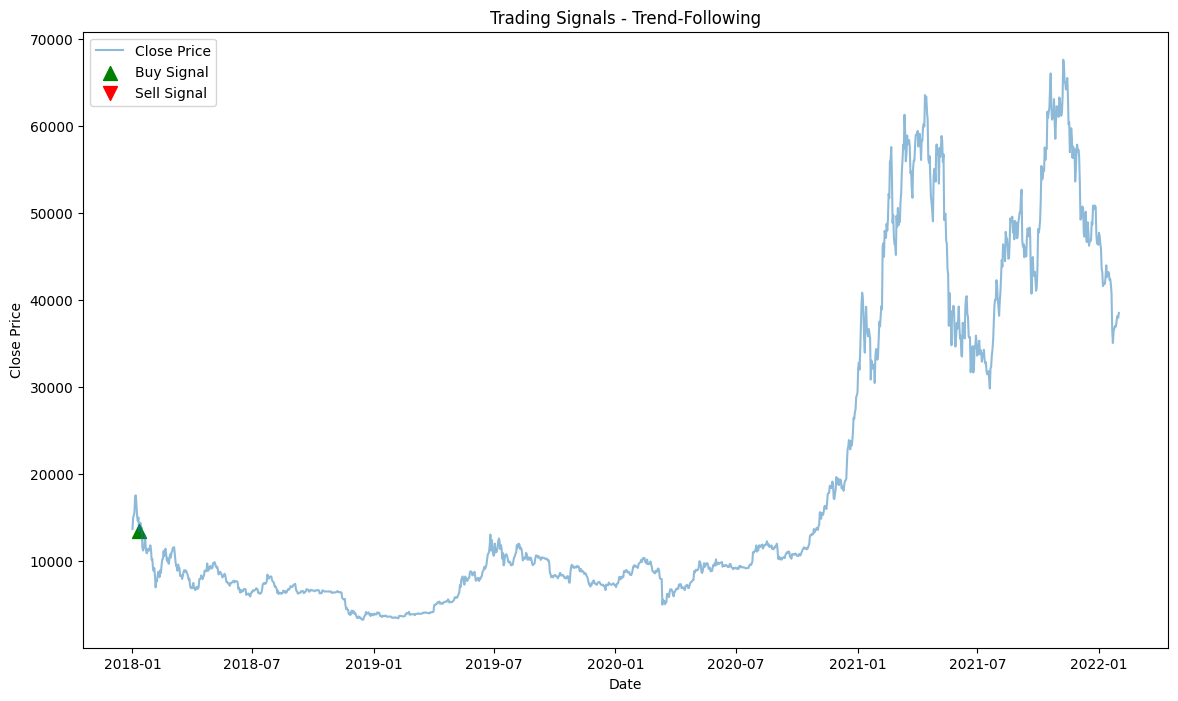

In [ ]:
# Visualize Strategy
def visualize_strategy(data, df1, strategy_name):
    plt.figure(figsize=(14, 8))
    plt.plot(data['Close'], label='Close Price', alpha=0.5)

    # Plot buy signals
    buy_signals = df1[df1['positions'] == 1].index
    plt.scatter(buy_signals, data.loc[buy_signals, 'Close'],
                marker='^', color='g', label='Buy Signal', s=100)

    # Plot sell signals
    sell_signals = df1[df1['positions'] == -1].index
    plt.scatter(sell_signals, data.loc[sell_signals, 'Close'],
                marker='v', color='r', label='Sell Signal', s=100)

    plt.title(f'Trading Signals - {strategy_name}')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.show()

# Backtest and Analyze Trend-Following Strategy
signals_trend_following = trend_strategy(btcusd)
btcusd_backtest_trend_following, trend_following_annual_returns, trend_following_drawdown = backtest_strategy(btcusd, signals_trend_following, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_trend_following, 'Trend-Following')

Annual Returns: 12.98%
Maximum Drawdown: -0.00%



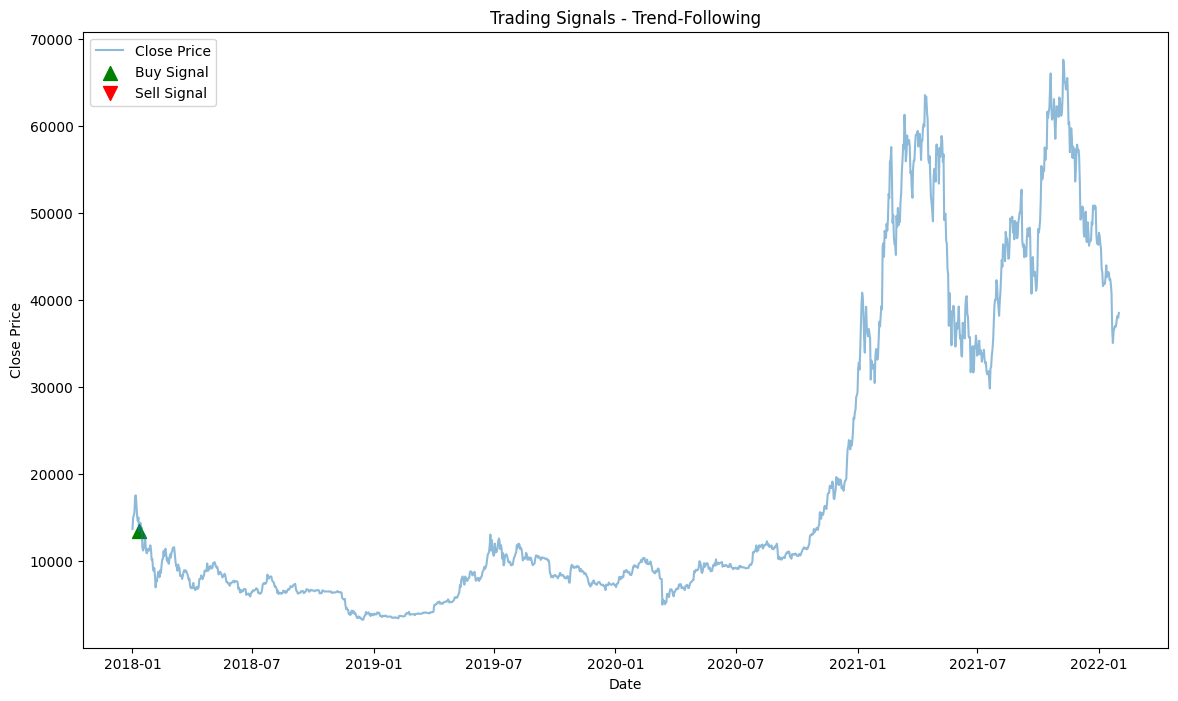

In [ ]:
# Backtest and Analyze Trend Strategy
signals_trend_following = trend_strategy(btcusd)
btcusd_backtest_trend_following, trend_following_annual_returns, trend_following_drawdown = backtest_strategy(btcusd, signals_trend_following, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_trend_following, 'Trend-Following')

Annual Returns: 0.05%
Maximum Drawdown: 34.22%



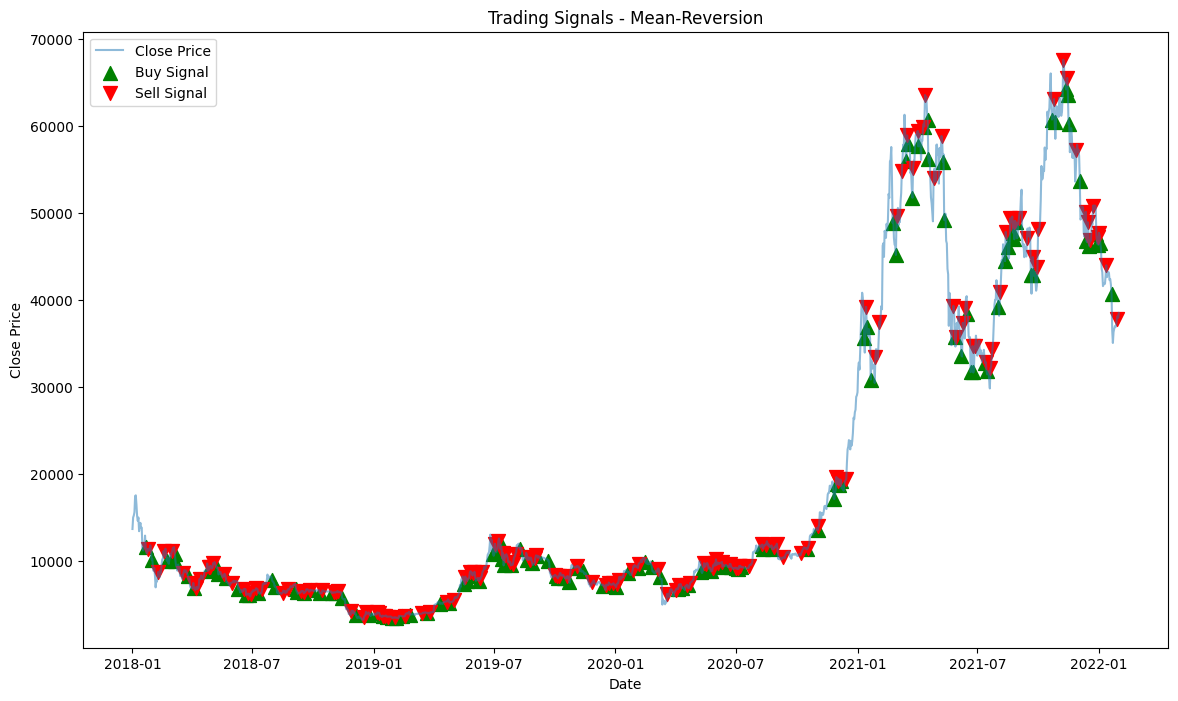

In [ ]:
# Backtest and Analyze Mean Reversion Strategy
signals_mean_reversion = mean_reversion_strategy(btcusd)
btcusd_backtest_mean_reversion, mean_reversion_annual_returns, mean_reversion_drawdown = backtest_strategy(btcusd, signals_mean_reversion, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_mean_reversion, 'Mean-Reversion')

Annual Returns: -2.08%
Maximum Drawdown: 11.69%



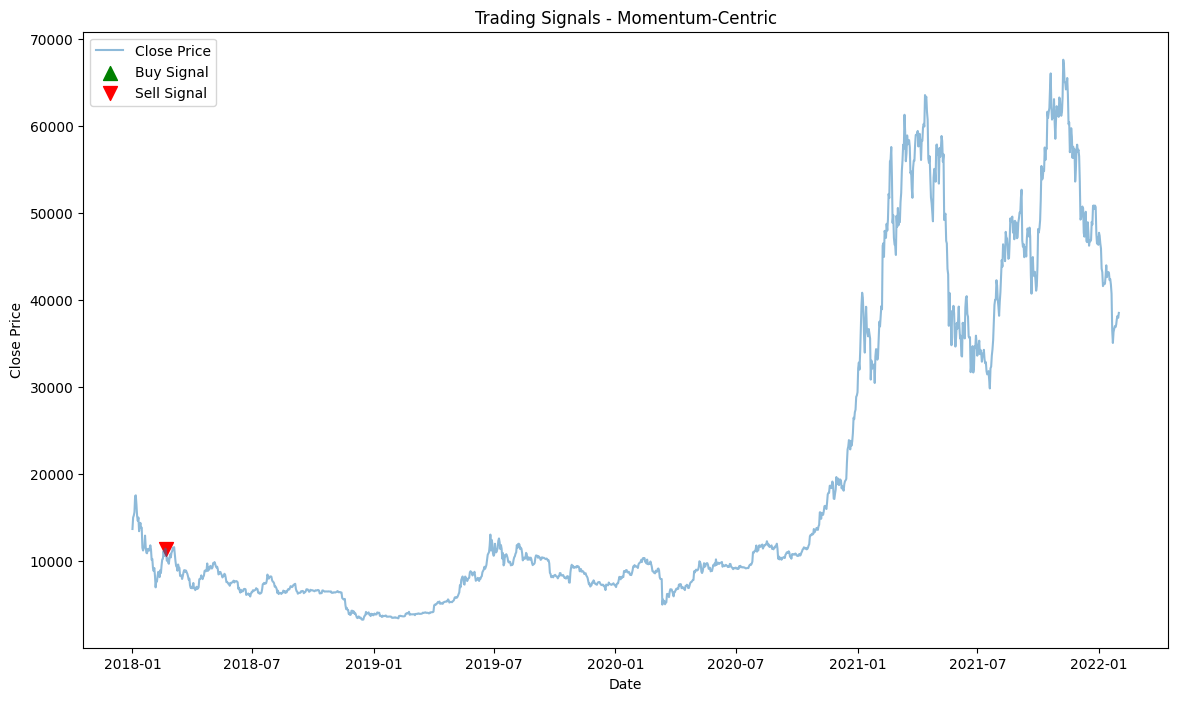

In [ ]:
# Backtest and Analyze Momentum-Centric Strategy
signals_momentum_centric = momentum_centric_strategy(btcusd)
btc_data_backtest_momentum_centric, momentum_centric_annual_returns, momentum_centric_drawdown = backtest_strategy(btcusd, signals_momentum_centric, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_momentum_centric, 'Momentum-Centric')

Training Accuracy: 100.00%
Test Accuracy: 99.48%
Annual Returns: 6.35%
Maximum Drawdown: -0.00%



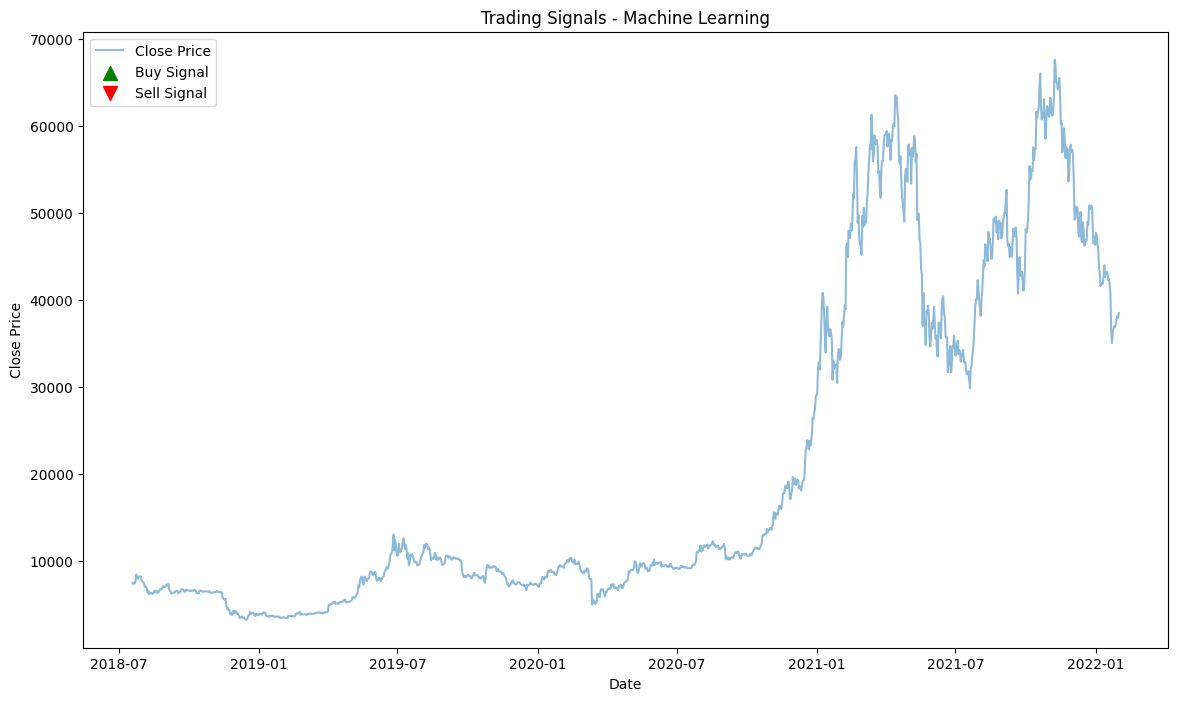

In [ ]:
# Backtest and Analyze Machine Learning Strategy
signals_ml = ml_strategy(btcusd)
btc_data_backtest_machine_learning, machine_learning_annual_returns, machine_learning_drawdown = backtest_strategy(btcusd, signals_ml, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_ml, 'Machine Learning')

In [ ]:
# Load  dataset
data = 'BTC-USD.csv'  # Replace with the path to your dataset
btcusd = pd.read_csv(data, parse_dates=True, index_col='Date')
btcusd

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-01,14112.200195,14112.200195,13154.700195,13657.200195,13657.200195,10291200000
2018-01-02,13625.000000,15444.599609,13163.599609,14982.099609,14982.099609,16846600192
2018-01-03,14978.200195,15572.799805,14844.500000,15201.000000,15201.000000,16871900160
2018-01-04,15270.700195,15739.700195,14522.200195,15599.200195,15599.200195,21783199744
2018-01-05,15477.200195,17705.199219,15202.799805,17429.500000,17429.500000,23840899072
...,...,...,...,...,...,...
2022-01-27,36841.878906,37148.324219,35629.281250,37138.234375,37138.234375,25041426629
2022-01-28,37128.445313,37952.878906,36211.109375,37784.332031,37784.332031,22238830523
2022-01-29,37780.714844,38576.261719,37406.472656,38138.179688,38138.179688,17194183075


In [ ]:
#with new featurs
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
def machinelearning_strategy_with_new_features(df, short_window=10, long_window=50):
    # Create short simple moving average
    df['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Generate signals based on moving average crossover
    df['signal'] = np.where(df['short_mavg'] > df['long_mavg'], 1, -1)

    df.dropna(inplace=True)

    X = df[['short_mavg', 'long_mavg', 'returns']]  # Add other features as needed
    y = df['signal']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    df1 = pd.DataFrame(index=X_test.index)
    df1['signal'] = np.where(y_pred == 1, 1.0, -1.0)

    df1['positions'] = df1['signal'].diff()

    # Evaluate the model on the training set
    training_accuracy = accuracy_score(y_train, clf.predict(X_train_scaled))
    print(f"Training Accuracy: {training_accuracy:.2%}")

    # Evaluate the model on the test set
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {test_accuracy:.2%}")
    df['returns'] = df['Close'].pct_change()
    return df1

Training Accuracy: 100.00%
Test Accuracy: 95.98%
Annual Returns: 4.07%
Maximum Drawdown: 55.25%



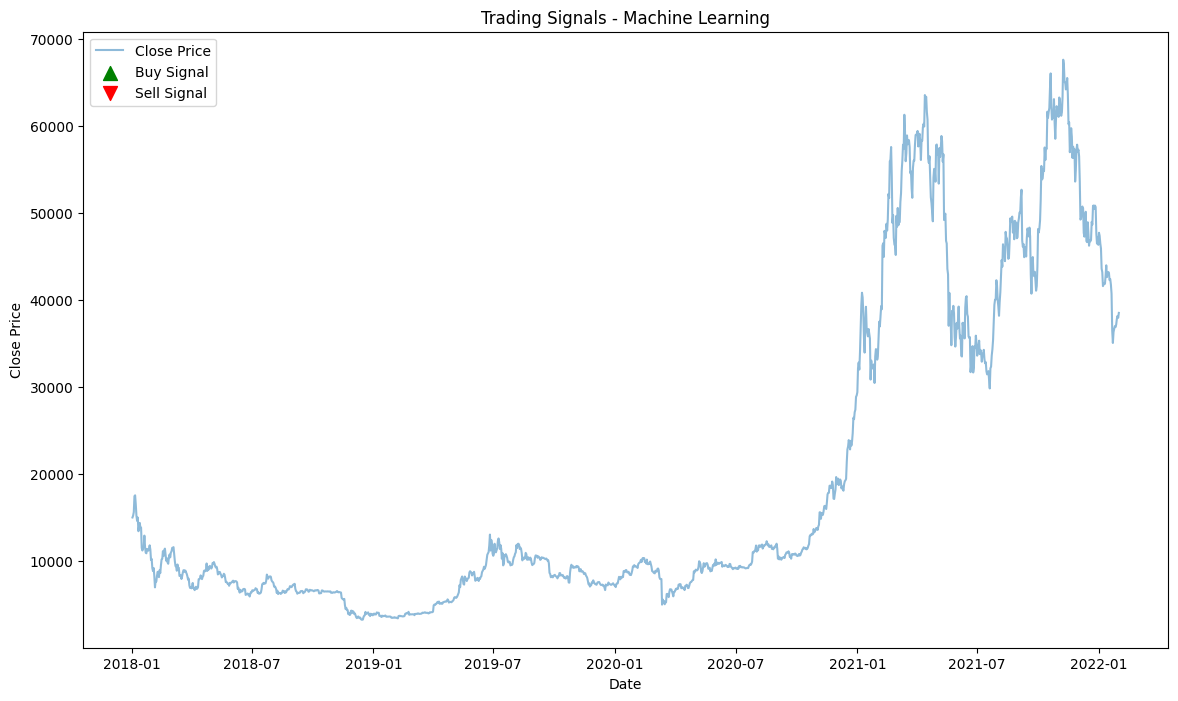

In [ ]:
# Backtest and Analyze Machine Learning Strategy
df1_machine_learning =  machinelearning_strategy_with_new_features(btcusd)
btc_data_backtest_machine_learning, machine_learning_annual_returns, machine_learning_drawdown = backtest_strategy(btcusd, df1_machine_learning, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_ml, 'Machine Learning')

In [ ]:
def mean_reversion_strategy_with_new_features(df, lookback_period=30, z_score_threshold=1.0, short_window=10, long_window=50):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Create short simple moving average
    df['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Calculate the rolling mean and standard deviation
    rolling_mean = df['Close'].rolling(window=lookback_period).mean()
    rolling_std = df['Close'].rolling(window=lookback_period).std()

    # Calculate z-score
    z_score = (df['Close'] - rolling_mean) / rolling_std

    # Generate signals based on z-score and moving average crossover
    df1['signal'][z_score < -z_score_threshold] = 1.0
    df1['signal'][z_score > z_score_threshold] = -1.0
    df1['signal'][(df['short_mavg'] > df['long_mavg']) & (z_score > -z_score_threshold)] = 0.0

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    return df1




Annual Returns: -7.10%
Maximum Drawdown: 49.38%



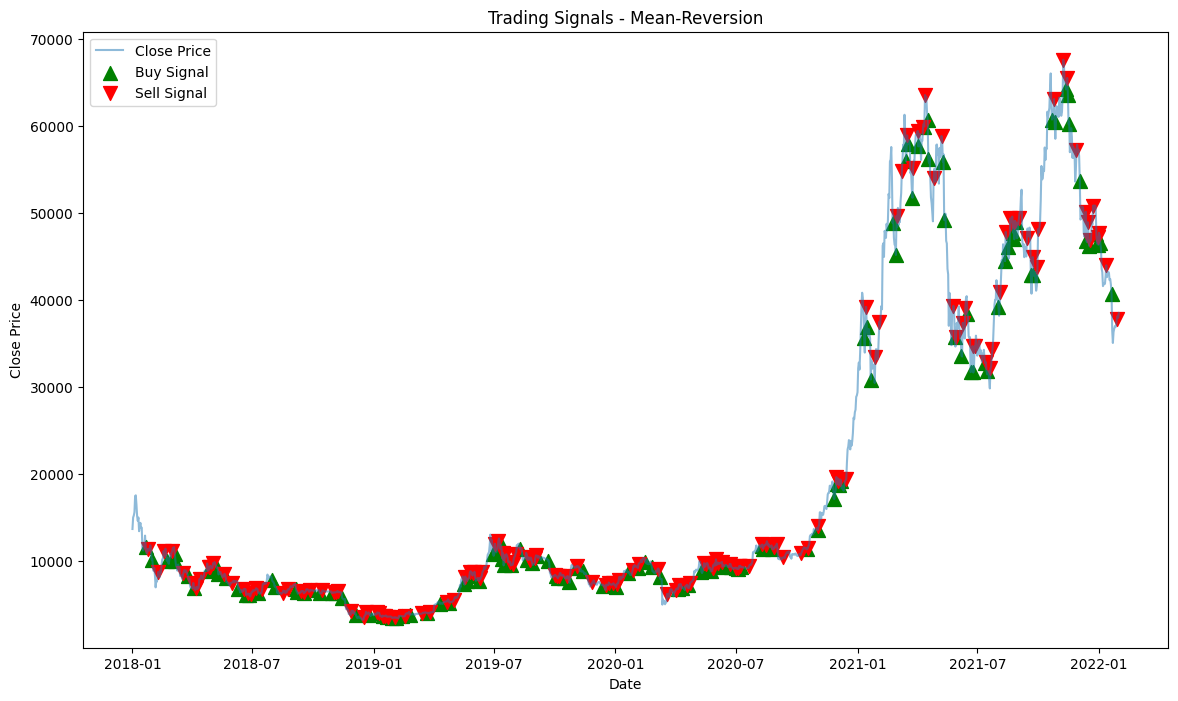

In [ ]:
df1_mean_reversion = mean_reversion_strategy_with_new_features(btcusd)
btcusd_backtest_mean_reversion, mean_reversion_annual_returns, mean_reversion_drawdown = backtest_strategy(btcusd, df1_mean_reversion, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_mean_reversion, 'Mean-Reversion')

In [ ]:
 def momentum_centric_strateg_ywith_new_features(df, short_window=50, long_window=200):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Create short simple moving average
    df1['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df1['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Generate signals based on moving average crossover
    df1['signal'][short_window:] = np.where(df1['short_mavg'][short_window:] > df1['long_mavg'][short_window:], 1.0, -1.0)

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    return df1

Annual Returns: -2.05%
Maximum Drawdown: 11.56%



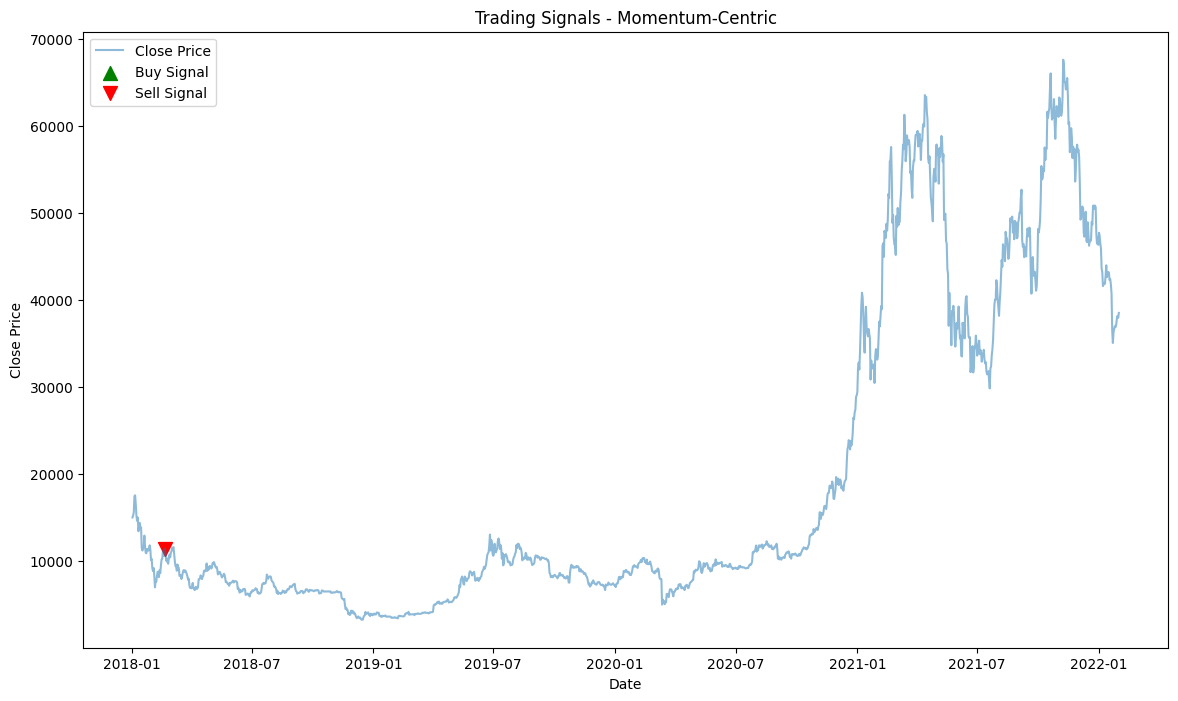

In [ ]:
# Backtest and Analyze Momentum-Centric Strategy
df1_momentum_centric = momentum_centric_strateg_ywith_new_features(btcusd)
btc_data_backtest_momentum_centric, momentum_centric_annual_returns, momentum_centric_drawdown = backtest_strategy(btcusd, df1_momentum_centric, transaction_cost_rate, slippage)
visualize_strategy(btcusd, signals_momentum_centric, 'Momentum-Centric')

In [ ]:
# Function to implement trend-following strategy with risk management
def trend_following_strategy_with_risk_management(df, short_window=10, long_window=50, risk_per_trade=0.05):
    df1 = pd.DataFrame(index=df.index)
    df1['signal'] = 0.0

    # Create short simple moving average
    df1['short_mavg'] = df['Close'].rolling(window=short_window, min_periods=1, center=False).mean()

    # Create long simple moving average
    df1['long_mavg'] = df['Close'].rolling(window=long_window, min_periods=1, center=False).mean()

    # Generate signals based on moving average crossover
    df1['signal'][short_window:] = np.where(df1['short_mavg'][short_window:] > df1['long_mavg'][short_window:], 1.0, -1.0)

    # Generate trading orders
    df1['positions'] = df1['signal'].diff()

    # Implement Risk Management
    capital = 100000  # Initial capital in USDT
    position = 0  # Initial position

    df['returns'] = df['Close'].pct_change()

    df['positions'] = df1['positions']

    stop_loss_triggered = False

    for i in range(1, len(df)):
        try:
            if df['positions'][i - 1] == 1:  # Long position
                if not stop_loss_triggered and df['Close'][i] <= df['Close'][i - 1] * (1 - risk_per_trade):
                    df['positions'][i] = 0  # Exit the position
                    stop_loss_triggered = True
                elif stop_loss_triggered:
                    df['positions'][i] = 0  # Exit the position if stop-loss is triggered
        except KeyError:
            pass  # Ignore KeyError

    # Calculate additional metrics
    df['cumulative_returns'] = (1 + df['returns']).cumprod() - 1
    #Gross Profit: Gross profit is a fundamental concept in accounting and finance, serving as an indicator of a company's profitability.
    df['gross_profit'] = np.where((df['returns'] > 0) & (df['positions'] == 1), df['returns'], 0)
    #Gross loss refers to the total loss incurred by a business before deducting any expenses. It is calculated by subtracting the cost of goods sold (COGS) from the total revenue.
    df['gross_loss'] = np.where((df['returns'] < 0) & (df['positions'] == 1), df['returns'], 0)
    #Net Profit: A company's net profit is also known as its net income, net earnings or bottom line. It represents the financial standing of a company after all its expenses have been paid off from its total revenue.
    df['net_profit'] = df['gross_profit'].sum() + df['gross_loss'].sum()
    #Total closed Trades: Total Closed Trades provide insight into the trading activity and the number of completed transactions within a given timeframe.
    df['total_closed_trades'] = df['positions'].eq(1).sum()
    #Win rate is how many trades you win, as a percentage, out of the total number of trades placed.
    df['win_rate'] = df['gross_profit'].gt(0).sum() / df['total_closed_trades']
    #Maximum drawdown (MDD) is a measure of an asset's largest price drop from a peak to a trough.
    df['maximum_drawdown'] = -df['cumulative_returns'].min()
    #The average winning trade represents the typical monetary gain per trade when a trader makes profitable transactions in USDT.
    df['average_winning_trade'] = df['gross_profit'].mean()
    #The average losing trade in USDT is determined by calculating the average amount lost in unsuccessful trades.
    df['average_losing_trade'] = df['gross_loss'].mean()
    #The Buy and Hold Return of BTC refers to the percentage change in the value of Bitcoin over a specific period when an investor buys and holds the asset without actively trading.
    df['buy_and_hold_return'] = (1 + df['returns']).prod() - 1
    #The largest losing trade in USDT represents the maximum monetary loss incurred in a single trading transaction, highlighting the most substantial negative impact on the trader's portfolio.
    df['largest_losing_trade'] = df['gross_loss'].min()
    #The "largest winning trade" metric represents the single most significant profit gained from a trade or a series of trades within a specified period.
    df['largest_winning_trade'] = df['gross_profit'].max()
    #The Sharpe ratio is a measure used to evaluate the risk-adjusted return of an investment, indicating the excess return per unit of risk in an investment strategy or trading system.
    df['sharpe_ratio'] = (df['returns'].mean() / df['returns'].std()) * np.sqrt(252)
    #The Sortino ratio measures the risk-adjusted return of an investment, focusing specifically on the downside risk, providing insight into an investment's performance relative to the downside volatility.
    df['sortino_ratio'] = (df['returns'].mean() / df['returns'].loc[df['returns'] < 0].std()) * np.sqrt(252)
    #The average holding duration refers to the average period for which an investment or trade is held before being sold or closed out.
    df['average_holding_duration'] = df['positions'].eq(1).sum() / df['total_closed_trades']

    # Print additional metrics
    print("Additional Metrics:")
    print(f'Gross Profit: {df["gross_profit"].sum()}')
    print(f'Net Profit: {df["net_profit"]}')
    print(f'Total Closed Trades: {df["total_closed_trades"]}')
    print('Win Rate: {:.2f}%'.format(df["win_rate"].iloc[0] * 100))
    print('Max Drawdown: {:.2f}%'.format(df["maximum_drawdown"].iloc[0] * 100))


    print(f'Average Winning Trade: {df["average_winning_trade"]}')
    print(f'Average Losing Trade: {df["average_losing_trade"]}')
    print('Buy and Hold Return of BTC: {:.2f}%'.format(df["buy_and_hold_return"].iloc[0] * 100))


    print(f'Largest Losing Trade: {df["largest_losing_trade"]}')
    print(f'Largest Winning Trade: {df["largest_winning_trade"]}')
    print(f'Sharpe Ratio: {df["sharpe_ratio"]}')
    print(f'Sortino Ratio: {df["sortino_ratio"]}')
    print(f'Average Holding Duration per Trade: {df["average_holding_duration"]}\n')
    print(df)
    print(df.columns)

    return df
# Backtest and analyze the trend-following strategy with risk management
btc_data_backtest = trend_following_strategy_with_risk_management(btcusd)



Additional Metrics:
Gross Profit: 0.04287694970542644
Net Profit: Date
2018-01-02    0.042877
2018-01-03    0.042877
2018-01-04    0.042877
2018-01-05    0.042877
2018-01-06    0.042877
                ...   
2022-01-27    0.042877
2022-01-28    0.042877
2022-01-29    0.042877
2022-01-30    0.042877
2022-01-31    0.042877
Name: net_profit, Length: 1491, dtype: float64
Total Closed Trades: Date
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
2018-01-06    1
             ..
2022-01-27    1
2022-01-28    1
2022-01-29    1
2022-01-30    1
2022-01-31    1
Name: total_closed_trades, Length: 1491, dtype: int64
Win Rate: 100.00%
Max Drawdown: 78.40%
Average Winning Trade: Date
2018-01-02    0.000029
2018-01-03    0.000029
2018-01-04    0.000029
2018-01-05    0.000029
2018-01-06    0.000029
                ...   
2022-01-27    0.000029
2022-01-28    0.000029
2022-01-29    0.000029
2022-01-30    0.000029
2022-01-31    0.000029
Name: average_winning_trade, Length: 1491, dtype: flo

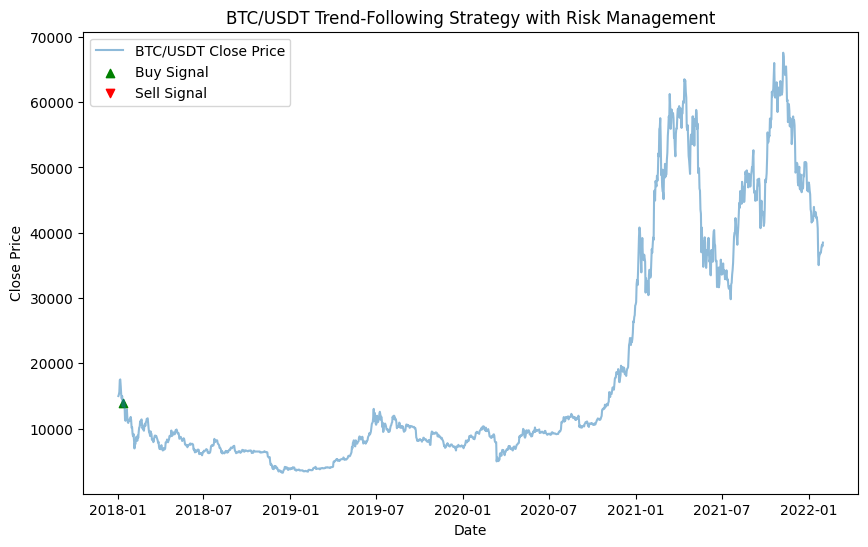

In [ ]:
# Visualize the results (you may need to modify this based on your preferred visualization library)
plt.figure(figsize=(10, 6))
plt.plot(btcusd['Close'], label='BTC/USDT Close Price', alpha=0.5)
buy_signals = btc_data_backtest.index[btc_data_backtest['positions'] == 1.0]
sell_signals = btc_data_backtest.index[btc_data_backtest['positions'] == -1.0]

plt.scatter(buy_signals, btc_data_backtest['Close'][btc_data_backtest['positions'] == 1.0], label='Buy Signal', marker='^', color='g')
plt.scatter(sell_signals, btc_data_backtest['Close'][btc_data_backtest['positions'] == -1.0], label='Sell Signal', marker='v', color='r')

plt.title('BTC/USDT Trend-Following Strategy with Risk Management')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()